# Analyse des avis et alertes ANSSI - Etapes 5 et 6

Ce notebook charge `donnees_consolidees.csv` (produit par `pipeline_anssi.py`),
puis realise :
- **Etape 5** : exploration et visualisations
- **Etape 6** : deux modeles de Machine Learning (non supervise + supervise) avec validation

## 0. Chargement des donnees

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("donnees_consolidees.csv")
print("Dimensions :", df.shape)
df.head()

Dimensions : (1344, 16)


,ID ANSSI,Titre ANSSI,Type,Date,CVE,Score CVSS,Base Severity,CWE,Score EPSS,Niveau EPSS,Priorite,Lien,Description,Editeur,Produit,Versions affectees
0,CERTFR-2023-ALE-007,[MàJ] Vulnérabilité dans Zimbra Collaboration ...,Alerte,2023-07-17,CVE-2023-37580,NaN,Inconnue,NaN,0.93918,Eleve,NaN,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Zimbra Collaboration (ZCS) 8 before 8.8.15 Pat...,NaN,NaN,NaN
1,CERTFR-2023-ALE-008,[MàJ] Vulnérabilité dans Citrix NetScaler ADC ...,Alerte,2023-07-19,CVE-2023-3519,9.8,Critique,CWE-94,0.93363,Eleve,9.15,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Unauthenticated remote code execution,Citrix,NetScaler ADC,"13.1, 13.0, 13.1-FIPS, 12.1-FIPS, 12.1-NDcPP"
2,CERTFR-2023-ALE-010,Multiples vulnérabilités dans Exim,Alerte,2023-10-02,CVE-2023-42118,7.5,Elevee,CWE-191,0.03014,Faible,0.23,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Exim libspf2 Integer Underflow Remote Code Exe...,Exim,libspf2,exim 4.96-RC0-14-24b8ed847-XX
3,CERTFR-2023-ALE-010,Multiples vulnérabilités dans Exim,Alerte,2023-10-02,CVE-2023-42116,8.1,Elevee,CWE-121,0.06734,Faible,0.55,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Exim SMTP Challenge Stack-based Buffer Overflo...,Exim,Exim,exim 4.95
4,CERTFR-2023-ALE-010,Multiples vulnérabilités dans Exim,Alerte,2023-10-02,CVE-2023-42115,9.8,Critique,CWE-787,0.65812,Eleve,6.45,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Exim AUTH Out-Of-Bounds Write Remote Code Exec...,Exim,Exim,exim 4.95


## Etape 5 - Exploration et visualisation

### 5.1 Exploration

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1344 entries, 0 to 1343
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID ANSSI            1344 non-null   str    
 1   Titre ANSSI         1344 non-null   str    
 2   Type                1344 non-null   str    
 3   Date                1344 non-null   str    
 4   CVE                 1344 non-null   str    
 5   Score CVSS          656 non-null    float64
 6   Base Severity       1344 non-null   str    
 7   CWE                 758 non-null    str    
 8   Score EPSS          1333 non-null   float64
 9   Niveau EPSS         1344 non-null   str    
 10  Priorite            656 non-null    float64
 11  Lien                1344 non-null   str    
 12  Description         1332 non-null   str    
 13  Editeur             1320 non-null   str    
 14  Produit             1326 non-null   str    
 15  Versions affectees  1318 non-null   str    
dtypes: float64(3), st

In [3]:
df[['Score CVSS', 'Score EPSS']].describe()

,Score CVSS,Score EPSS
count,656.000000,1333.000000
mean,7.320732,0.029831
std,1.581128,0.149559
min,0.400000,0.000030
25%,6.500000,0.000210
50%,7.800000,0.000400
75%,8.100000,0.000830
max,10.000000,0.944120


In [4]:
# Nombre de valeurs manquantes par colonne
df.isna().sum()

ID ANSSI                0
Titre ANSSI             0
Type                    0
Date                    0
CVE                     0
Score CVSS            688
Base Severity           0
CWE                   586
Score EPSS             11
Niveau EPSS             0
Priorite              688
Lien                    0
Description            12
Editeur                24
Produit                18
Versions affectees     26
dtype: int64

### 5.2 Distribution des scores CVSS

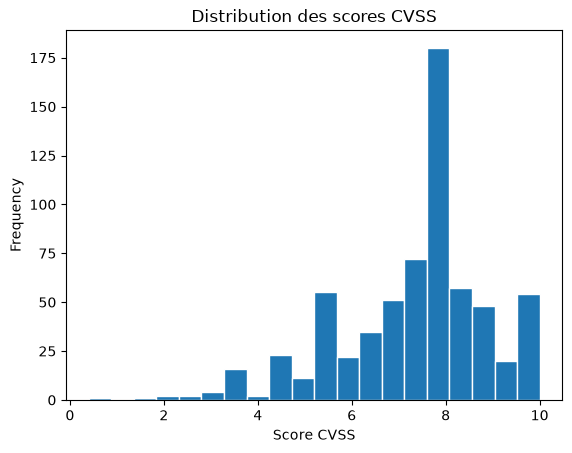

In [5]:
df["Score CVSS"].plot(kind="hist", bins=20, edgecolor="white")
plt.title("Distribution des scores CVSS")
plt.xlabel("Score CVSS")
plt.show()

### 5.3 Repartition par niveau de gravite

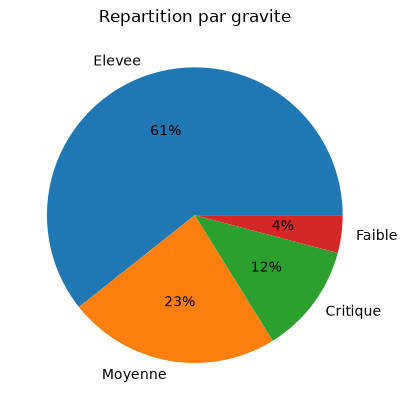

In [6]:
# on enleve les CVE sans score (gravite "Inconnue")
gravites = df[df["Base Severity"] != "Inconnue"]["Base Severity"].value_counts()
gravites.plot(kind="pie", autopct="%1.0f%%")
plt.title("Repartition par gravite")
plt.ylabel("")
plt.show()

### 5.4 Types de failles les plus frequents (CWE)

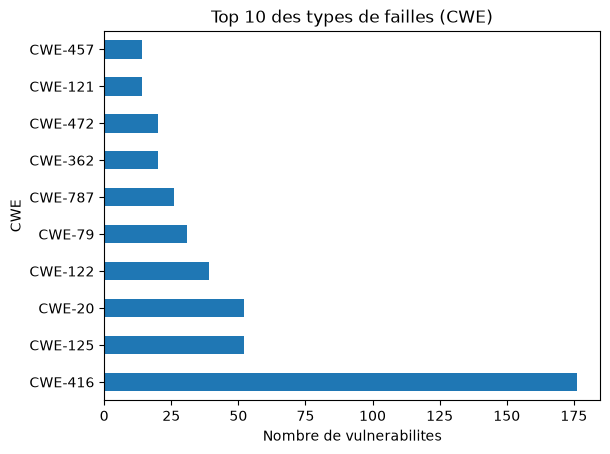

In [7]:
df["CWE"].value_counts().head(10).plot(kind="barh")
plt.title("Top 10 des types de failles (CWE)")
plt.xlabel("Nombre de vulnerabilites")
plt.show()

### 5.5 Editeurs les plus touches

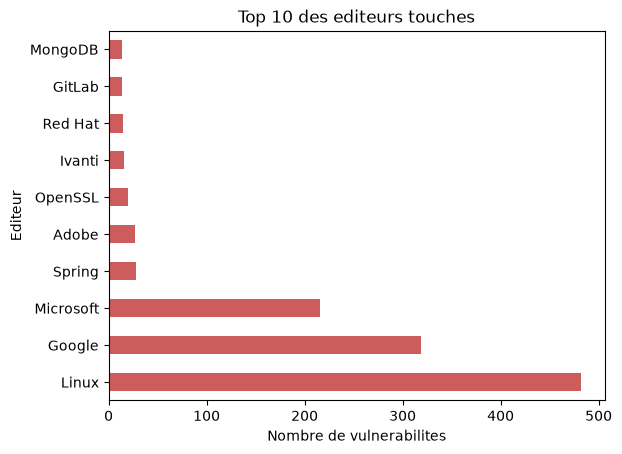

In [8]:
df["Editeur"].value_counts().head(10).plot(kind="barh", color="indianred")
plt.title("Top 10 des editeurs touches")
plt.xlabel("Nombre de vulnerabilites")
plt.show()

### 5.6 Gravite (CVSS) vs probabilite d'exploitation (EPSS)
On regarde si une vulnerabilite grave est aussi tres exploitee.

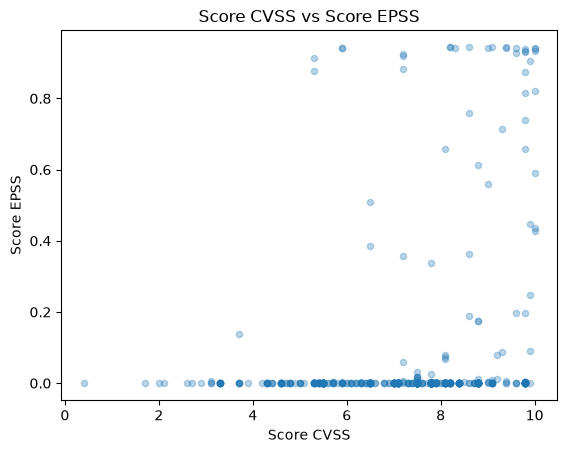

In [9]:
df.plot(kind="scatter", x="Score CVSS", y="Score EPSS", alpha=0.3)
plt.title("Score CVSS vs Score EPSS")
plt.show()

**Lecture :** les points sont disperses : une vulnerabilite grave n'est pas
forcement tres exploitee. Les deux scores sont donc complementaires.

### 5.7 Nombre de vulnerabilites par annee

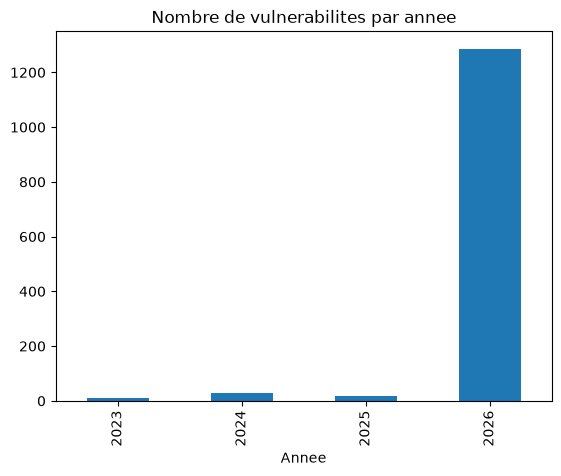

In [10]:
df["Annee"] = df["Date"].str[:4]
df["Annee"].value_counts().sort_index().plot(kind="bar")
plt.title("Nombre de vulnerabilites par annee")
plt.xlabel("Annee")
plt.show()

## Etape 6 - Machine Learning

- **Non supervise (KMeans)** : regrouper les vulnerabilites selon CVSS et EPSS.
- **Supervise (RandomForest)** : predire si une vulnerabilite est grave (CVSS >= 7)
  a partir d'autres informations.

### 6.1 Modele non supervise : KMeans

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# on garde les vulnerabilites qui ont un score CVSS ET un score EPSS
donnees = df.dropna(subset=["Score CVSS", "Score EPSS"]).copy()
X = donnees[["Score CVSS", "Score EPSS"]]

# mise a la meme echelle (CVSS va de 0 a 10, EPSS de 0 a 1)
X_norm = StandardScaler().fit_transform(X)
print("Nombre de vulnerabilites :", len(donnees))

Nombre de vulnerabilites : 656


**Choix du nombre de groupes : methode du coude.**

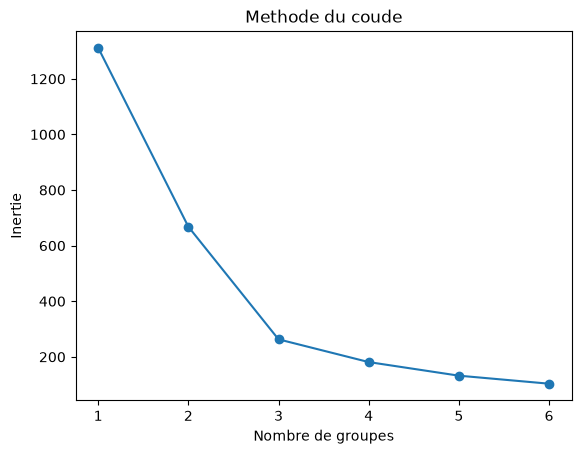

In [12]:
inerties = []
for n in range(1, 7):
    km = KMeans(n_clusters=n, n_init=10, random_state=0).fit(X_norm)
    inerties.append(km.inertia_)

plt.plot(range(1, 7), inerties, marker="o")
plt.title("Methode du coude")
plt.xlabel("Nombre de groupes")
plt.ylabel("Inertie")
plt.show()

In [13]:
# on choisit 3 groupes
modele = KMeans(n_clusters=3, n_init=10, random_state=0)
donnees["Groupe"] = modele.fit_predict(X_norm)

# validation : score de silhouette (proche de 1 = groupes bien separes)
print("Silhouette :", round(silhouette_score(X_norm, donnees["Groupe"]), 2))

Silhouette : 0.66


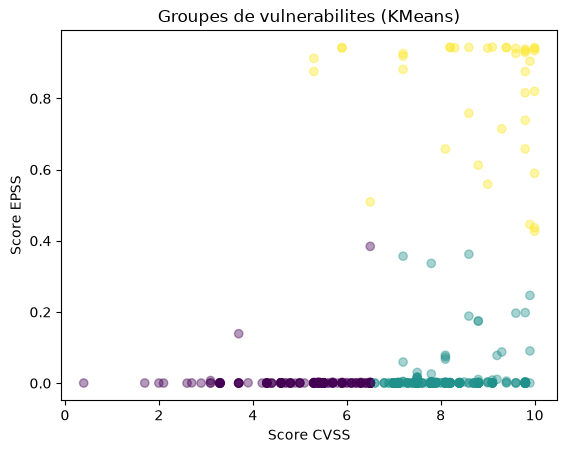

In [14]:
plt.scatter(donnees["Score CVSS"], donnees["Score EPSS"],
            c=donnees["Groupe"], cmap="viridis", alpha=0.4)
plt.title("Groupes de vulnerabilites (KMeans)")
plt.xlabel("Score CVSS")
plt.ylabel("Score EPSS")
plt.show()

In [15]:
# profil moyen de chaque groupe (pour les interpreter)
donnees.groupby("Groupe")[["Score CVSS", "Score EPSS"]].mean().round(2)

,Score CVSS,Score EPSS
Groupe,,
0,5.13,0.00
1,8.01,0.01
2,8.77,0.82


### 6.2 Modele supervise : RandomForest

In [16]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

ml = df.dropna(subset=["Score CVSS", "Score EPSS"]).copy()
ml["critique"] = (ml["Score CVSS"] >= 7).astype(int)   # 1 = grave, 0 = pas grave

# variables explicatives : EPSS, type de bulletin, type de faille (CWE)
# get_dummies transforme les categories en colonnes 0/1
X = pd.get_dummies(ml[["Score EPSS", "Type", "CWE"]])
y = ml["critique"]
print("Exemples :", len(X), "| Variables :", X.shape[1])

Exemples : 656 | Variables : 114


In [17]:
# decoupage entrainement / test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

modele = RandomForestClassifier(random_state=0)
modele.fit(X_train, y_train)
y_pred = modele.predict(X_test)

# validation
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.38      0.52        45
           1       0.80      0.97      0.88       119

    accuracy                           0.80       164
   macro avg       0.81      0.67      0.70       164
weighted avg       0.81      0.80      0.78       164



In [18]:
# matrice de confusion (reel vs predit)
pd.crosstab(y_test, y_pred, rownames=["reel"], colnames=["predit"])

predit,0,1
reel,,
0,17,28
1,4,115


In [19]:
# validation croisee (5 decoupages) pour verifier la stabilite
print("Validation croisee :", cross_val_score(modele, X, y, cv=5).round(2))

Validation croisee : [0.66 0.82 0.76 0.67 0.74]


## Conclusion

- Beaucoup de vulnerabilites sont de gravite **moyenne a elevee**, avec quelques cas
  **critiques** prioritaires.
- CVSS et EPSS sont **peu lies** : il faut croiser les deux pour bien prioriser.
- Le **KMeans** trouve des groupes de risque, et le **RandomForest** predit la gravite
  mieux que le hasard (validation par jeu de test + validation croisee).